# Explorary Data Analysis

## Package Import & Path Settings

In [70]:

from pathlib import Path
import pandas as pd
from pandas import DataFrame as df
import numpy as np
import matplotlib.pyplot as plt
import json

from PIL import Image, UnidentifiedImageError

# pytorch
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset

# data split
from sklearn.model_selection import train_test_split

# preprocessing & structure
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer

# baseline models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error

# others
from concurrent.futures import ThreadPoolExecutor

# path settings
from src import MODELS_DIR, PARAMS_PATH, SEED, PET_IMAGES_DIR, get_device
DEVICE = get_device()
print(f'Device: {DEVICE}')
print(f'MODELS_DIR: {MODELS_DIR}')
print(f'PARAMS_PATH: {PARAMS_PATH}')
print(f'SEED: {SEED}')
print(f'PET_IMAGES_DIR: {PET_IMAGES_DIR}')

label = {0:'cat', 1:'dog'}


Device: cpu
MODELS_DIR: C:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\outputs\models
PARAMS_PATH: C:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\outputs\params
SEED: 37
PET_IMAGES_DIR: C:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\data\raw\PetImages


## Data Loading

In [67]:

def get_meta(path):
    with Image.open(path) as im:
        return im.mode, im.size[0], im.size[1]

def is_valid_image(path: str) -> bool:
    try:
        # verify() checks file integrity without fully decoding pixel data
        with Image.open(path) as im:
            im.verify()
        return True
    except (UnidentifiedImageError, OSError):
        return False

ds = ImageFolder(PET_IMAGES_DIR)


### Corrupted Files

In [75]:

with ThreadPoolExecutor() as ex:
    bad_idx = [i for i, valid in enumerate(ex.map(is_valid_image, (p for p, _ in ds.samples))) if not valid]

ds_bad = Subset(ds, bad_idx)

print(f"Total: {len(ds)}, Bad: {len(ds_bad)}, Bad: {len(ds) - len(ds_bad)}")


c:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Total: 25000, Bad: 2, Bad: 24998


In [68]:

print('Path of corrupted files:')
bad_path_list = []
for i in ds_bad.indices:
    bad_path = ds_bad.dataset.samples[i][0]
    bad_path_list.append(bad_path)
    print(bad_path)

with open('bad_files.json', 'w') as f:
    json.dump(bad_path_list, f)


Path of corrupted files:
C:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\data\raw\PetImages\Cat\666.jpg
C:\Coding Stuff\Python\kaggle\kaggle-image-classification-cats_dogs\data\raw\PetImages\Dog\11702.jpg


In [76]:
bad_set = {str(Path(p).resolve()) for p in bad_path_list}
ds.samples = [(p, y) for (p, y) in ds.samples if str(Path(p).resolve()) not in bad_set]
ds.imgs = ds.samples
ds.targets = [y for _, y in ds.samples]

In [77]:


idx = list(range(len(ds)))
y = ds.targets

In [79]:
ds_stat_df = pd.DataFrame(ds.samples, columns=['path', 'id'])
    
with ThreadPoolExecutor() as ex:
    modes, widths, heights = zip(*ex.map(get_meta, ds_df['path'].tolist()))

ds_stat_df["mode"] = modes
ds_stat_df["width"] = widths
ds_stat_df["height"] = heights

<Axes: xlabel='height'>

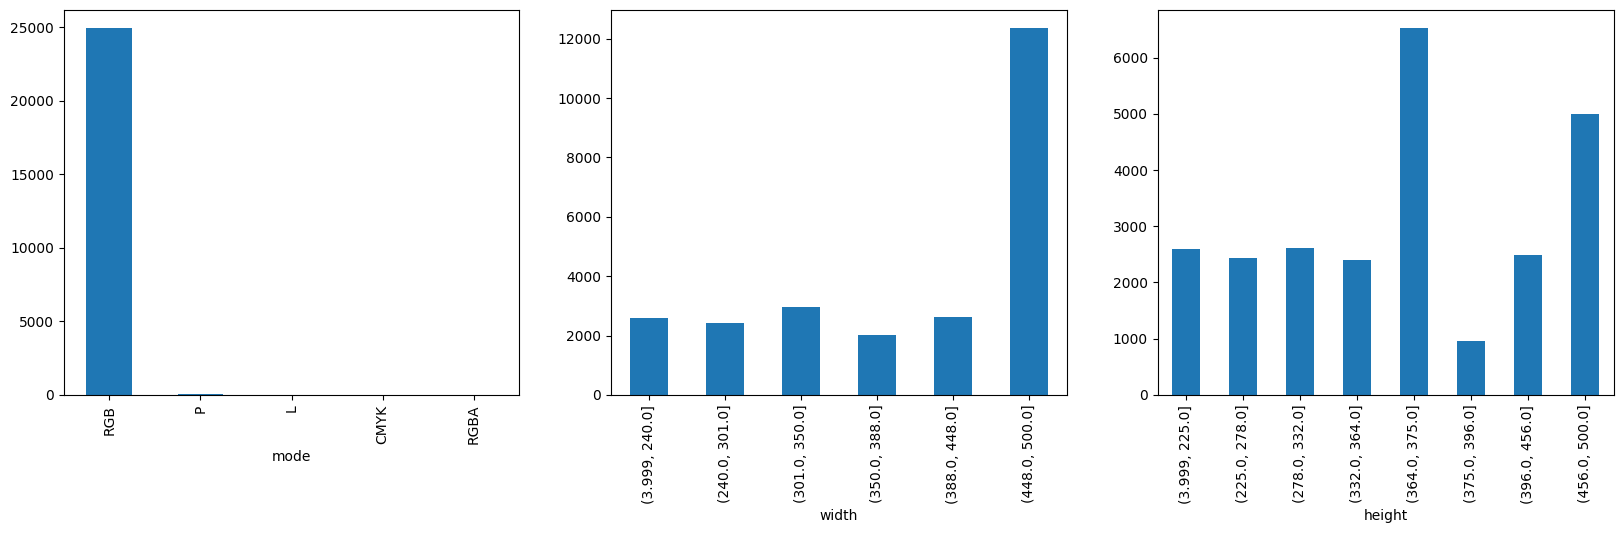

In [81]:

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ds_stat_df['mode'].value_counts().plot(kind='bar', ax=ax[0])

pd.qcut(ds_stat_df['width'], 10, duplicates='drop').value_counts().sort_index().plot(kind='bar', ax=ax[1])
pd.qcut(ds_stat_df['height'], 10, duplicates='drop').value_counts().sort_index().plot(kind='bar', ax=ax[2])

Random draw from the dataset shows that the images inside have different dimensions.

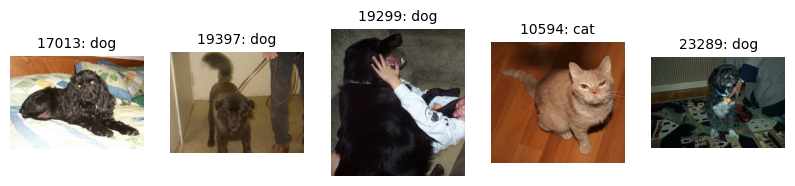

In [20]:
fig, ax = plt.subplots(1, 5, figsize=(10, 30))
for i, idx in enumerate(np.random.randint(0, len(ds) + 1, 5)):
    ax[i].imshow(ds[idx][0])
    ax[i].set_title(f'{idx}: {label[ds[idx][1]]}', fontsize=10)
    ax[i].set_axis_off()
